# Exploratory Data Analysis

## Objectives
- Inspect the annotation schema and the available label names.
- Distinguish annotation counts from unique-image counts.
- Validate reader coverage and bounding-box coordinates.
- Analyze image-level voting and spatial agreement separately.
- Explore multi-label distributions and finding co-occurrence.
- Analyze bounding-box sizes relative to image dimensions.
- Visualize candidate consensus masks.

## Prerequisites
Download and prepare the dataset following README.md.

## Scope
All analyses in this notebook use the available training annotations.
Dataset coverage and label availability must be verified from the actual files.

In [6]:
# libraries
import os
import cv2
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from itertools import combinations
from IPython.display import display


In [7]:
# Replace this with your actual GitHub repository URL.
REPO_URL = "https://github.com/HuyDuongQuoc/DATH-HK261-explainable-cxr.git"

WORK_DIR = (
    Path("/content")
    if Path("/content").is_dir()
    else Path.cwd()
)

PROJECT_ROOT = WORK_DIR / "dath_cxr_repo"

if "<username>" in REPO_URL or "<repo>" in REPO_URL:
    raise ValueError(
        "Replace REPO_URL with your actual GitHub repository URL."
    )

if (PROJECT_ROOT / ".git").exists():
    print("Using existing cloned repository:", PROJECT_ROOT)
elif PROJECT_ROOT.exists():
    raise FileExistsError(
        f"The destination exists but is not a Git repository: "
        f"{PROJECT_ROOT}"
    )
else:
    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(PROJECT_ROOT),
        ],
        check=True,
    )

print("PROJECT_ROOT:", PROJECT_ROOT)

Using existing cloned repository: /content/dath_cxr_repo
PROJECT_ROOT: /content/dath_cxr_repo


In [8]:
# Install the dataset downloader in the notebook's Python environment.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "kagglehub",
    ],
    check=True,
)

import kagglehub

DATASET_HANDLE = (
    "sunghyunjun/vinbigdata-1024-jpg-dataset"
)

# Use the actual directory returned by KaggleHub.
DATA_DIR = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
).resolve()

print("Downloaded dataset directory:", DATA_DIR)


# Locate train.csv, allowing an extra directory level inside the downloaded dataset.
csv_candidates = sorted(
    DATA_DIR.rglob("train.csv")
)

if len(csv_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one train.csv in the downloaded dataset. "
        f"Found: {[str(path) for path in csv_candidates]}"
    )

TRAIN_CSV = csv_candidates[0]


def find_image_directory(dataset_dir, split):
    candidates = sorted(
        path
        for path in dataset_dir.rglob(split)
        if path.is_dir()
        and any(path.glob("*.jpg"))
    )

    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Expected exactly one '{split}' directory "
            f"containing JPG images. "
            f"Found: {[str(path) for path in candidates]}"
        )

    return candidates[0]


TRAIN_DIR = find_image_directory(DATA_DIR, "train")
TEST_DIR = find_image_directory(DATA_DIR, "test")

# Verify that the selected CSV has the annotation schema expected by the existing EDA code.
required_columns = {
    "image_id",
    "class_name",
    "rad_id",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
}

csv_columns = set(
    pd.read_csv(TRAIN_CSV, nrows=0).columns
)

if not required_columns.issubset(csv_columns):
    raise ValueError(
        f"The selected CSV does not have the expected "
        f"annotation columns: {TRAIN_CSV}"
    )

EDA_DIR = PROJECT_ROOT / "outputs" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("EDA_DIR:", EDA_DIR)

Using Colab cache for faster access to the 'vinbigdata-1024-jpg-dataset' dataset.
Downloaded dataset directory: /kaggle/input/vinbigdata-1024-jpg-dataset
PROJECT_ROOT: /content/dath_cxr_repo
DATA_DIR: /kaggle/input/vinbigdata-1024-jpg-dataset
TRAIN_CSV: /kaggle/input/vinbigdata-1024-jpg-dataset/train.csv
TRAIN_DIR: /kaggle/input/vinbigdata-1024-jpg-dataset/train
TEST_DIR: /kaggle/input/vinbigdata-1024-jpg-dataset/test
EDA_DIR: /content/dath_cxr_repo/outputs/eda


In [9]:
df = pd.read_csv(TRAIN_CSV)

df = df.loc[:, ~df.columns.str.startswith("Unnamed:")].copy()

required_columns = {
    "image_id", "class_name", "rad_id",
    "x_min", "y_min", "x_max", "y_max",
}

assert required_columns.issubset(df.columns)

ID_COLUMNS = ["image_id", "class_name", "rad_id"]
BOX_COLUMNS = ["x_min", "y_min", "x_max", "y_max"]

if df.empty:
    raise ValueError("The annotation table is empty.")

if df[ID_COLUMNS].isna().any().any():
    raise ValueError("Missing image ID, class name, or reader ID.")

# Keep missing bbox values; reject nonnumeric coordinate strings.
df[BOX_COLUMNS] = df[BOX_COLUMNS].apply(
    pd.to_numeric,
    errors="raise",
)

EXPECTED_READERS = 3
POSITIVE_VOTES = 2

print("Annotation rows:", len(df))
print("Unique images:", df["image_id"].nunique())
print("Classes:", sorted(df["class_name"].unique()))

display(df.head())
display(df.isna().sum().to_frame("missing_count"))

reader_counts = df.groupby("image_id")["rad_id"].nunique()
display(reader_counts.value_counts().sort_index().to_frame("image_count"))

unexpected_readers = reader_counts[
    reader_counts != EXPECTED_READERS
]

if not unexpected_readers.empty:
    display(unexpected_readers.to_frame("reader_count"))
    raise ValueError(
        "Some images do not have exactly three recorded readers. "
        "Inspect the annotation coverage before applying majority voting."
    )

# A reader should not mark both No finding and an abnormal finding for the same image under the protocol used here.
reader_status = (
    df.assign(
        is_no_finding=df["class_name"].eq("No finding"),
        is_abnormal=df["class_name"].ne("No finding"),
    )
    .groupby(["image_id", "rad_id"])[
        ["is_no_finding", "is_abnormal"]
    ]
    .any()
)

conflicting = reader_status[
    reader_status["is_no_finding"]
    & reader_status["is_abnormal"]
]

if not conflicting.empty:
    display(conflicting)
    raise ValueError(
        "Conflicting No finding and abnormal annotations "
        "for the same image-reader pair."
    )

duplicate_columns = ID_COLUMNS + BOX_COLUMNS

print(
    "Exact duplicate annotation rows:",
    int(df.duplicated(subset=duplicate_columns).sum()),
)

Annotation rows: 67914
Unique images: 15000
Classes: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'No finding', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
1,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
2,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
3,183015e171f5159d7e60d43578632a3f,Aortic enlargement,0,R8,567.0,295.0,671.0,417.0,1134.0,1342.0,721.0,1019.0,2048.0,2500.0,0.500000,0.409600
4,183015e171f5159d7e60d43578632a3f,Pleural thickening,11,R9,58.0,794.0,116.0,851.0,117.0,232.0,1938.0,2077.0,2048.0,2500.0,0.500000,0.409600


,missing_count
image_id,0
class_name,0
class_id,0
rad_id,0
x_min,31818
y_min,31818
x_max,31818
y_max,31818
raw_x_min,31818
raw_x_max,31818


,image_count
rad_id,
3,15000


Exact duplicate annotation rows: 0


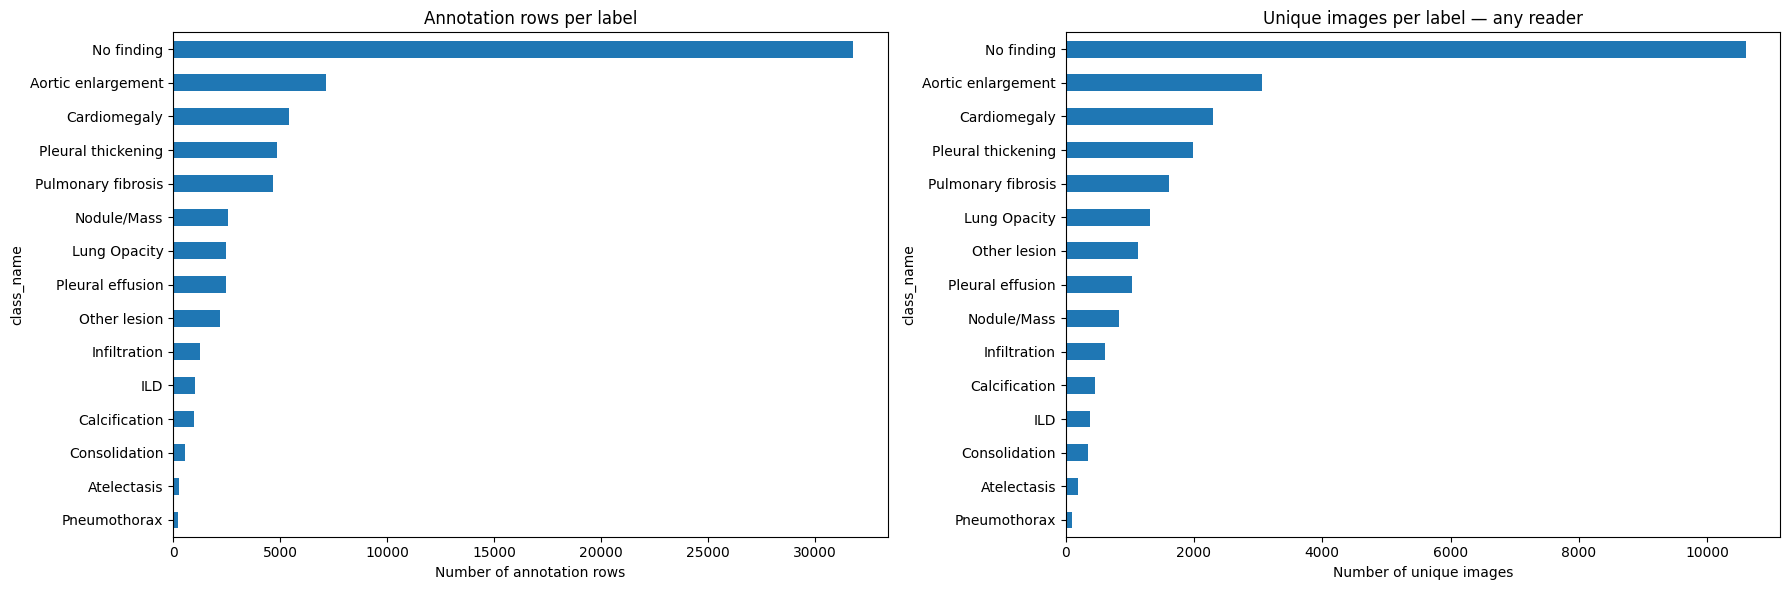

In [10]:
# Distinguish number of annoatation and number of pictures

annotation_counts = df["class_name"].value_counts()

image_counts = (
    df[["image_id", "class_name"]]
    .drop_duplicates()
    ["class_name"]
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

annotation_counts.sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Annotation rows per label")
axes[0].set_xlabel("Number of annotation rows")

image_counts.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Unique images per label — any reader")
axes[1].set_xlabel("Number of unique images")

plt.tight_layout()
plt.savefig(EDA_DIR / "annotation_vs_image_counts.png", dpi=150)
plt.show()

In [11]:
abnormal_df = df[df["class_name"] != "No finding"].copy()

# Doctors draw some bbox with finding still count 1 vote
votes = (
    abnormal_df
    .groupby(["image_id", "class_name"])["rad_id"]
    .nunique()
    .rename("positive_readers")
    .reset_index()
)

total_images = df["image_id"].nunique()
summary_rows = []

for finding, group in votes.groupby("class_name"):
    positive_majority = int((group["positive_readers"] >= 2).sum())

    summary_rows.append({
        "finding": finding,
        "images_any_reader": len(group),
        "images_1_reader": int((group["positive_readers"] == 1).sum()),
        "images_2_readers": int((group["positive_readers"] == 2).sum()),
        "images_3_readers": int((group["positive_readers"] == 3).sum()),
        "positive_majority": positive_majority,
        "negative_majority": total_images - positive_majority,
        "positive_rate": positive_majority / total_images,
    })

summary = (
    pd.DataFrame(summary_rows)
    .sort_values("positive_majority", ascending=False)
)

summary["images_0_readers"] = (
    total_images - summary["images_any_reader"]
)

summary["minority_only_rate"] = (
    summary["images_1_reader"]
    / summary["images_any_reader"]
)

assert (
    summary[
        [
            "images_0_readers",
            "images_1_reader",
            "images_2_readers",
            "images_3_readers",
        ]
    ].sum(axis=1)
    == total_images
).all()

display(summary)
summary.to_csv(EDA_DIR / "finding_summary.csv", index=False)

,finding,images_any_reader,images_1_reader,images_2_readers,images_3_readers,positive_majority,negative_majority,positive_rate,images_0_readers,minority_only_rate
0,Aortic enlargement,3067,721,602,1744,2346,12654,0.156400,11933,0.235083
3,Cardiomegaly,2300,483,520,1297,1817,13183,0.121133,12700,0.210000
13,Pulmonary fibrosis,1617,600,384,633,1017,13983,0.067800,13383,0.371058
11,Pleural thickening,1981,1099,517,365,882,14118,0.058800,13019,0.554770
10,Pleural effusion,1032,398,195,439,634,14366,0.042267,13968,0.385659
7,Lung Opacity,1322,775,380,167,547,14453,0.036467,13678,0.586233
8,Nodule/Mass,826,421,224,181,405,14595,0.027000,14174,0.509685
9,Other lesion,1134,772,235,127,362,14638,0.024133,13866,0.680776
6,Infiltration,613,368,154,91,245,14755,0.016333,14387,0.600326
2,Calcification,452,275,120,57,177,14823,0.011800,14548,0.608407


## Annotation workload by radiologist

The next chart shows the number of annotation rows contributed
by each radiologist.

A reader may draw multiple boxes on one image. Therefore,
annotation-row counts do not equal image counts.

This chart describes annotation workload. It does not directly
measure reader agreement, diagnostic accuracy, or annotator bias.

,annotation_rows,unique_images
rad_id,,
R9,15708,6125
R10,13292,6467
R8,12198,6582
R2,3121,3119
R5,2783,2783
R3,2285,2285
R6,2041,2041
R1,1995,1995
R13,1824,1629


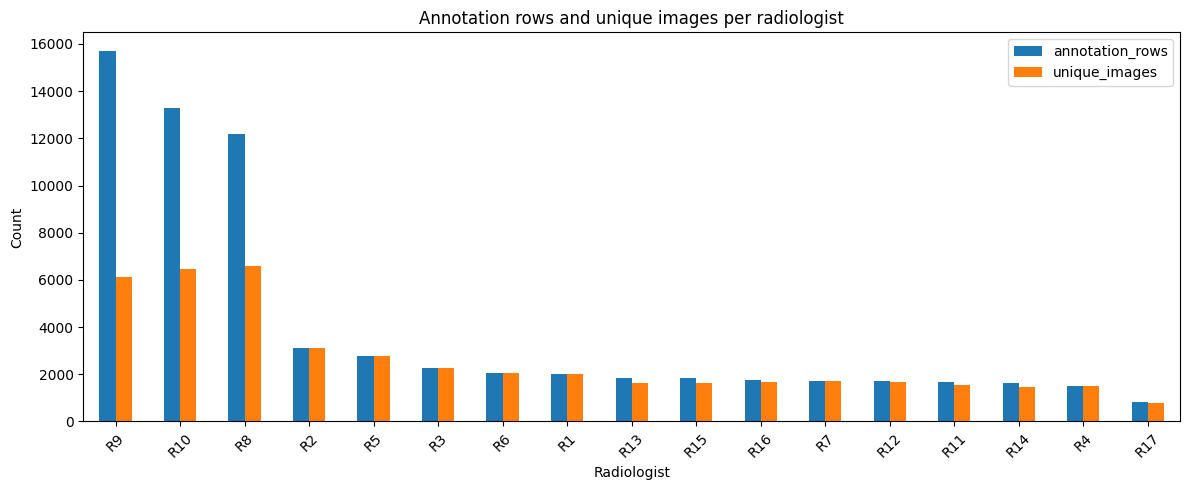

In [12]:
reader_workload = (
    df.groupby("rad_id")
    .agg(
        annotation_rows=("image_id", "size"),
        unique_images=("image_id", "nunique"),
    )
    .sort_values("annotation_rows", ascending=False)
)

display(reader_workload)

reader_workload.plot.bar(
    figsize=(12, 5),
)

plt.title("Annotation rows and unique images per radiologist")
plt.xlabel("Radiologist")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    EDA_DIR / "reader_workload.png",
    dpi=150,
)
plt.show()

reader_workload.to_csv(
    EDA_DIR / "reader_workload.csv",
)

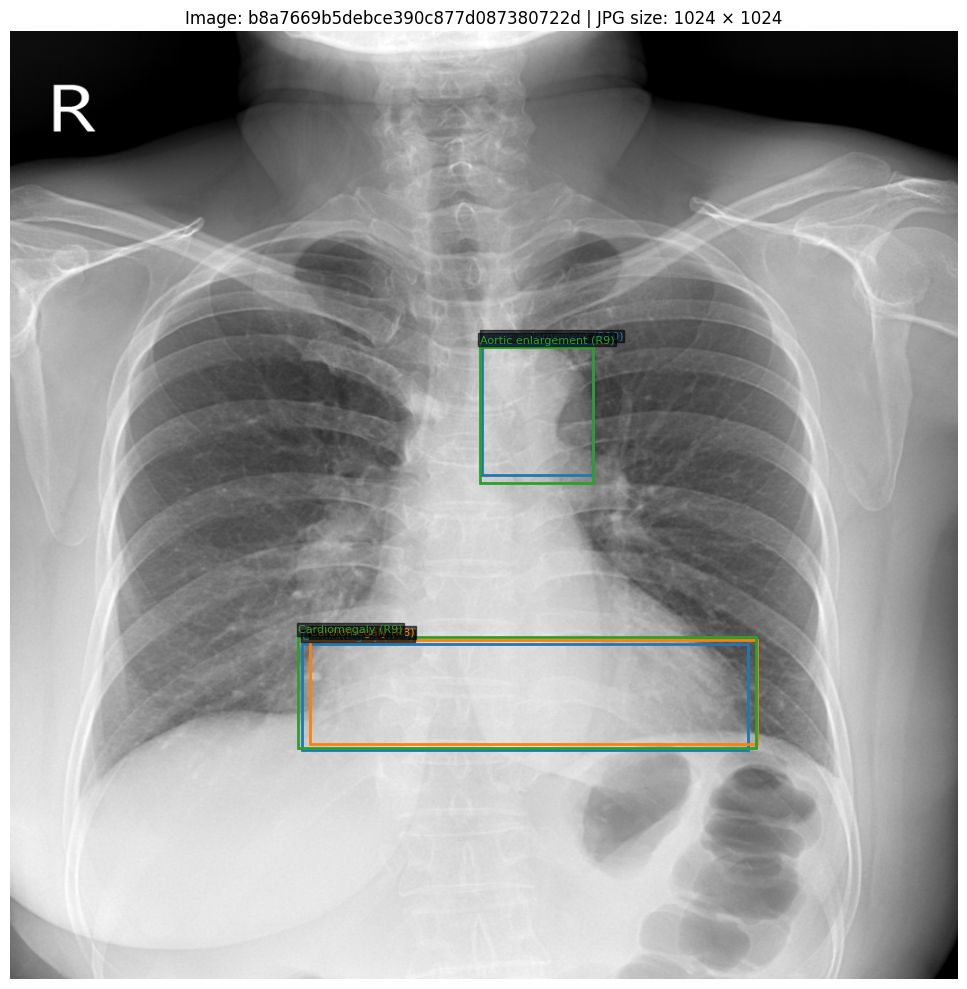

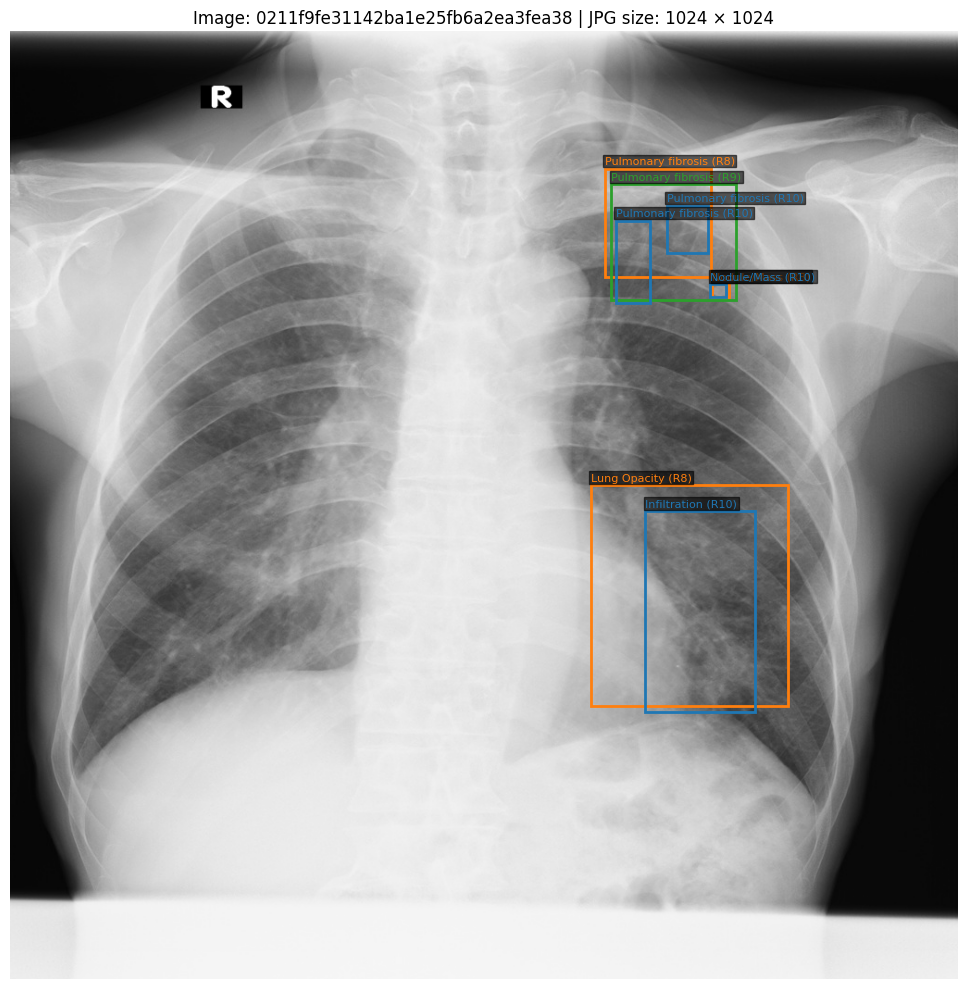

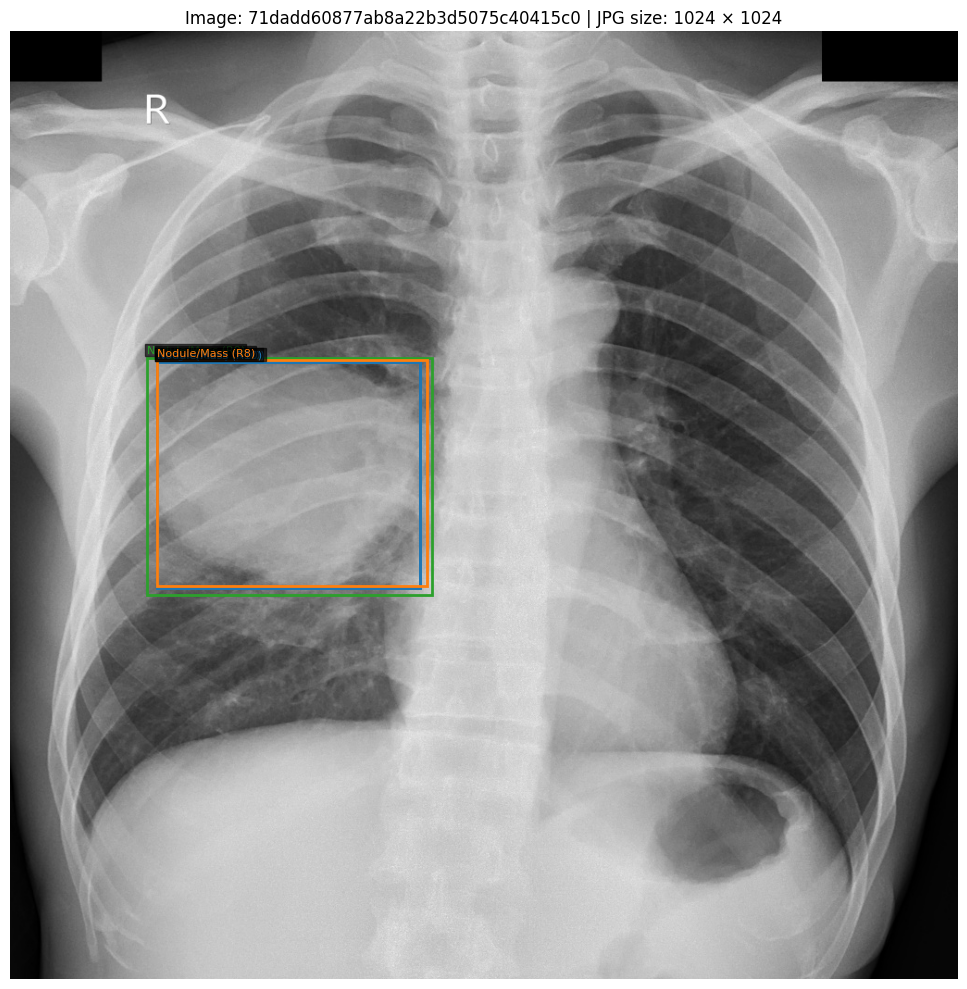

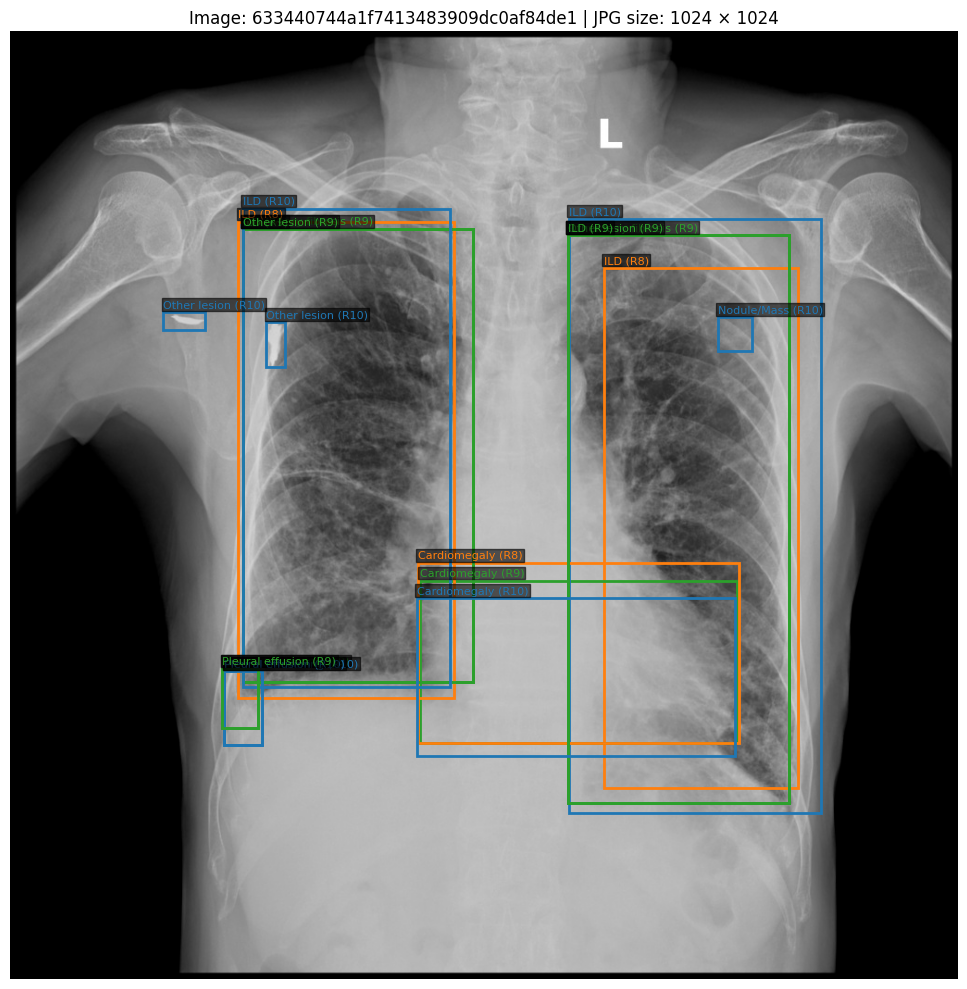

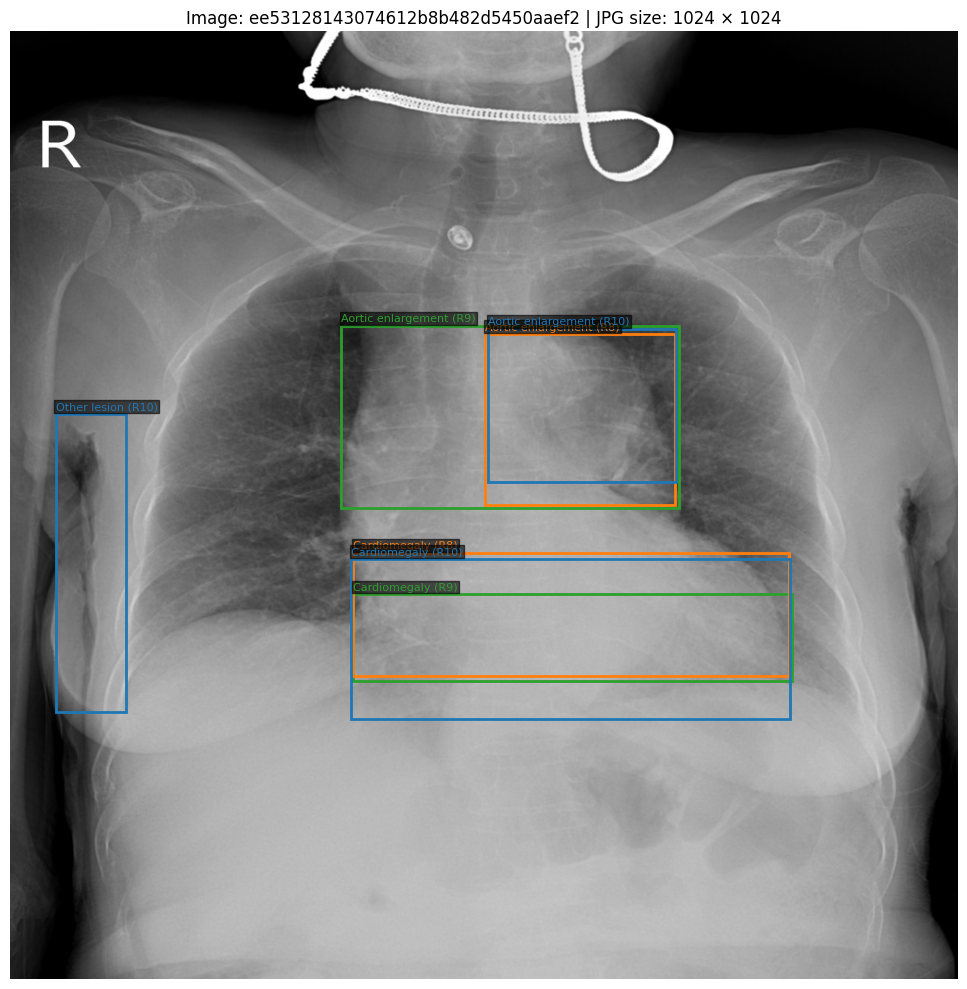

In [13]:
def plot_cxr_img(
    image_id,
    annotations,
    image_dir,
    class_name=None,
):
    image_path = Path(image_dir) / f"{image_id}.jpg"

    img = cv2.imread(str(image_path))

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    height, width = img.shape[:2]

    rows = annotations.loc[
        annotations["image_id"].eq(image_id)
        & annotations["class_name"].ne("No finding")
    ].copy()

    if class_name is not None:
        rows = rows.loc[
            rows["class_name"].eq(class_name)
        ]

    readers = sorted(rows["rad_id"].unique())
    cmap = plt.get_cmap("tab10")

    reader_colors = {
        reader: cmap(index % 10)
        for index, reader in enumerate(readers)
    }

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    for row in rows.itertuples(index=False):
        coords = np.asarray(
            [
                row.x_min,
                row.y_min,
                row.x_max,
                row.y_max,
            ],
            dtype=float,
        )

        if not np.isfinite(coords).all():
            raise ValueError(f"Nonfinite abnormal bbox: {image_id}")

        x0, y0, x1, y1 = coords

        if not (
            0 <= x0 < x1 <= width
            and 0 <= y0 < y1 <= height
        ):
            raise ValueError(
                f"Bbox outside JPG dimensions: {image_id}, "
                f"bbox={coords.tolist()}, "
                f"image_size={(width, height)}"
            )

        color = reader_colors[row.rad_id]

        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )

        ax.add_patch(rect)

        ax.text(
            x0,
            max(0, y0 - 5),
            f"{row.class_name} ({row.rad_id})",
            color=color,
            fontsize=8,
            bbox={
                "facecolor": "black",
                "alpha": 0.6,
                "pad": 1,
            },
        )

    ax.set_title(f"Image: {image_id} | JPG size: {width} × {height}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

abnormal_ids = (
    df.loc[
        df["class_name"].ne("No finding"),
        "image_id",
    ]
    .drop_duplicates()
)

sample_ids = abnormal_ids.sample(
    n=min(5, len(abnormal_ids)),
    random_state=42,
)

for image_id in sample_ids:
    plot_cxr_img(
        image_id,
        df,
        TRAIN_DIR,
    )

# Problem 1: Available labels and bounding-box validity

Local findings have spatial annotations, such as bounding boxes.
Their presence can also be used to construct image-level
classification targets.

Global diagnoses are image-level labels. Their availability
must be verified from the corresponding source files.

An image without a bounding box is not automatically a
global-diagnosis sample.

This notebook first inspects the actual labels and bounding-box
coverage in train.csv. It does not assume that this file contains
all labels from the full VinDr-CXR release.

In [14]:
label_inventory = (
    df.assign(
        has_complete_bbox=df[BOX_COLUMNS].notna().all(axis=1)
    )
    .groupby("class_name")
    .agg(
        annotation_rows=("image_id", "size"),
        unique_images=("image_id", "nunique"),
        complete_bbox_rows=("has_complete_bbox", "sum"),
    )
    .sort_values("unique_images", ascending=False)
)

label_inventory["incomplete_bbox_rows"] = (
    label_inventory["annotation_rows"] - label_inventory["complete_bbox_rows"]
)

display(label_inventory)

label_inventory.to_csv(
    EDA_DIR / "label_inventory.csv",
)

# This stage expects abnormal rows in this bbox annotation file to contain spatial annotations.
df_local = df.loc[
    df["class_name"].ne("No finding")
].copy()

LOCAL_LABELS = sorted(df_local["class_name"].unique())

print("Observed abnormal labels:", LOCAL_LABELS)
print("Number of observed abnormal labels:", len(LOCAL_LABELS))

no_finding_rows = df.loc[
    df["class_name"].eq("No finding")
]

print(
    "No finding rows containing any bbox coordinate:",
    int(no_finding_rows[BOX_COLUMNS].notna().any(axis=1).sum()),
)

# Check image-file coverage.
image_paths = {
    path.stem: path
    for path in TRAIN_DIR.iterdir()
    if path.is_file()
    and path.suffix.lower() == ".jpg"
}

csv_ids = set(df["image_id"])
jpg_ids = set(image_paths)

missing_jpg = sorted(csv_ids - jpg_ids)
unannotated_jpg = sorted(jpg_ids - csv_ids)

print("CSV IDs without JPG:", len(missing_jpg))
print("JPG IDs without annotation:", len(unannotated_jpg))

if missing_jpg:
    print("Examples:", missing_jpg[:10])
    raise FileNotFoundError(
        "Some annotated images have no corresponding JPG."
    )

# Read actual JPG dimensions; this may take a while.
image_dimensions = {}

for image_id in sorted(csv_ids):
    with Image.open(image_paths[image_id]) as image:
        image_dimensions[image_id] = image.size

bbox_audit = df_local.copy()

bbox_audit["jpg_width"] = bbox_audit["image_id"].map(
    lambda image_id: image_dimensions[image_id][0]
)

bbox_audit["jpg_height"] = bbox_audit["image_id"].map(
    lambda image_id: image_dimensions[image_id][1]
)

coords = bbox_audit[BOX_COLUMNS].to_numpy(dtype=float)

bbox_audit["finite"] = np.isfinite(coords).all(axis=1)

bbox_audit["valid_order"] = (
    bbox_audit["x_min"].lt(bbox_audit["x_max"])
    & bbox_audit["y_min"].lt(bbox_audit["y_max"])
)

bbox_audit["inside_jpg"] = (
    bbox_audit["x_min"].ge(0)
    & bbox_audit["y_min"].ge(0)
    & bbox_audit["x_max"].le(bbox_audit["jpg_width"])
    & bbox_audit["y_max"].le(bbox_audit["jpg_height"])
)

bbox_audit["valid_bbox"] = (
    bbox_audit["finite"]
    & bbox_audit["valid_order"]
    & bbox_audit["inside_jpg"]
)

invalid_boxes = bbox_audit.loc[
    ~bbox_audit["valid_bbox"]
]

bbox_audit.to_csv(
    EDA_DIR / "bbox_audit.csv",
    index=False,
)

print("Abnormal bbox rows:", len(bbox_audit))
print("Invalid abnormal bbox rows:", len(invalid_boxes))

if not invalid_boxes.empty:
    display(invalid_boxes.head(20))
    raise ValueError(
        "Invalid abnormal bounding boxes. "
        "Resolve their source or coordinate system before continuing."
    )

# Downstream spatial analyses use audited annotations.
df_findings = df_local.copy()

print("Available CSV files:")
for path in sorted(DATA_DIR.rglob("*.csv")):
    print(path.relative_to(DATA_DIR))
    
print(label_inventory)

,annotation_rows,unique_images,complete_bbox_rows,incomplete_bbox_rows
class_name,,,,
No finding,31818,10606,0,31818
Aortic enlargement,7162,3067,7162,0
Cardiomegaly,5427,2300,5427,0
Pleural thickening,4842,1981,4842,0
Pulmonary fibrosis,4655,1617,4655,0
Lung Opacity,2483,1322,2483,0
Other lesion,2203,1134,2203,0
Pleural effusion,2476,1032,2476,0
Nodule/Mass,2580,826,2580,0


Observed abnormal labels: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
Number of observed abnormal labels: 14
No finding rows containing any bbox coordinate: 0
CSV IDs without JPG: 0
JPG IDs without annotation: 0
Abnormal bbox rows: 36096
Invalid abnormal bbox rows: 0
Available CSV files:
train.csv


,class_name,box_count,percentage (%),image_count_any_reader
0,Aortic enlargement,7162,19.841534,3067
1,Cardiomegaly,5427,15.034907,2300
2,Pleural thickening,4842,13.414229,1981
3,Pulmonary fibrosis,4655,12.896166,1617
4,Nodule/Mass,2580,7.147606,826
5,Lung Opacity,2483,6.878879,1322
6,Pleural effusion,2476,6.859486,1032
7,Other lesion,2203,6.103169,1134
8,Infiltration,1247,3.454676,613
9,ILD,1000,2.770390,386


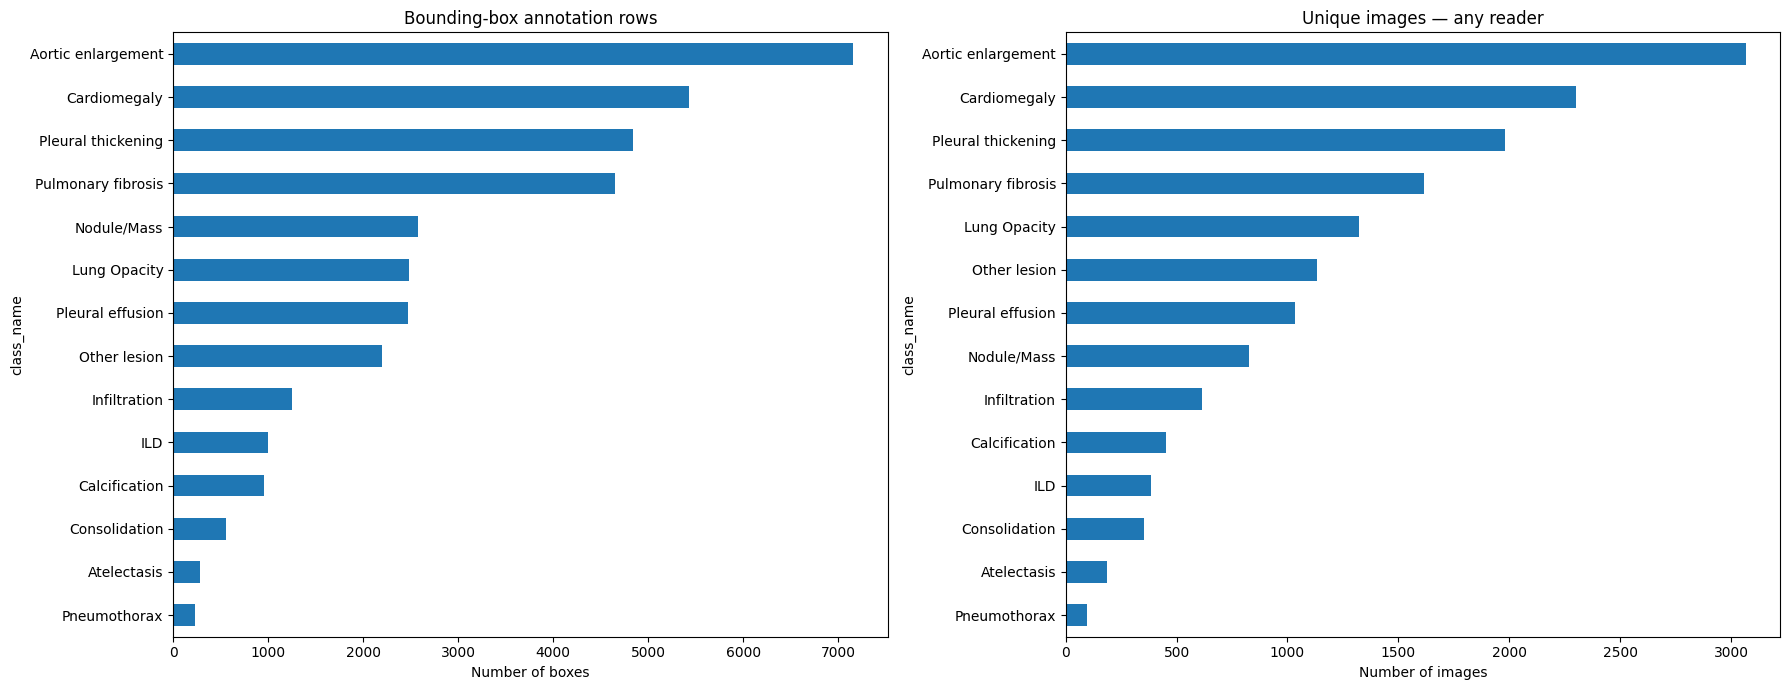

In [15]:
local_counts = (
    df_findings["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="box_count")
)

local_counts["percentage (%)"] = (
    local_counts["box_count"]
    / local_counts["box_count"].sum()
    * 100
)

local_image_counts = (
    df_findings.groupby("class_name")["image_id"]
    .nunique()
)

local_counts["image_count_any_reader"] = (
    local_counts["class_name"].map(local_image_counts)
)

display(local_counts)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

(
    local_counts.set_index("class_name")["box_count"]
    .sort_values()
    .plot.barh(ax=axes[0])
)

axes[0].set_title("Bounding-box annotation rows")
axes[0].set_xlabel("Number of boxes")

(
    local_counts.set_index("class_name")["image_count_any_reader"]
    .sort_values()
    .plot.barh(ax=axes[1])
)

axes[1].set_title("Unique images — any reader")
axes[1].set_xlabel("Number of images")

plt.tight_layout()
plt.savefig(
    EDA_DIR / "local_label_counts.png",
    dpi=150,
)
plt.show()

local_counts.to_csv(
    EDA_DIR / "local_label_counts.csv",
    index=False,
)

# Problem 2: Reader agreement

## Image-level voting
Count distinct readers who report a finding on an image.
Multiple boxes from the same reader contribute one vote.

The vote distribution below is conditional on at least one
reader reporting the finding. It excludes image-finding pairs
with zero positive votes.

## Spatial agreement
Compare the annotated regions of readers who both report
the same finding on the same image.

Image-level agreement does not imply spatial agreement.

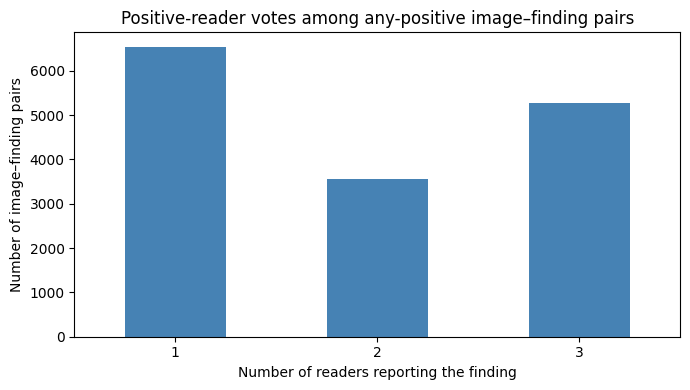

doctor_votes,1,2,3
class_name,,,
Aortic enlargement,23.51,19.63,56.86
Cardiomegaly,21.00,22.61,56.39
Lung Opacity,58.62,28.74,12.63
Nodule/Mass,50.97,27.12,21.91
Other lesion,68.08,20.72,11.20
Pleural effusion,38.57,18.90,42.54
Pleural thickening,55.48,26.10,18.43
Pulmonary fibrosis,37.11,23.75,39.15


In [16]:
doctor_agreement = (
    votes.loc[
        votes["class_name"].isin(LOCAL_LABELS)
    ]
    .rename(
        columns={"positive_readers": "doctor_votes"}
    )
    .copy()
)

vote_summary = (
    doctor_agreement["doctor_votes"]
    .value_counts()
    .reindex([1, 2, 3], fill_value=0)
)

vote_summary.plot.bar(
    figsize=(7, 4),
    color="steelblue",
)

plt.title("Positive-reader votes among any-positive image–finding pairs")
plt.xlabel("Number of readers reporting the finding")
plt.ylabel("Number of image–finding pairs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    EDA_DIR / "positive_reader_votes.png",
    dpi=150,
)
plt.show()

top8_classes = (
    summary.loc[
        summary["finding"].isin(LOCAL_LABELS)
    ]
    .head(8)["finding"]
    .tolist()
)

selected_agreement = doctor_agreement.loc[
    doctor_agreement["class_name"].isin(top8_classes)
]

agreement_pivot = pd.crosstab(
    selected_agreement["class_name"],
    selected_agreement["doctor_votes"],
    normalize="index",
).reindex(
    columns=[1, 2, 3],
    fill_value=0,
) * 100

display(agreement_pivot.round(2))

agreement_pivot.to_csv(
    EDA_DIR / "positive_vote_distribution_per_class.csv",
)

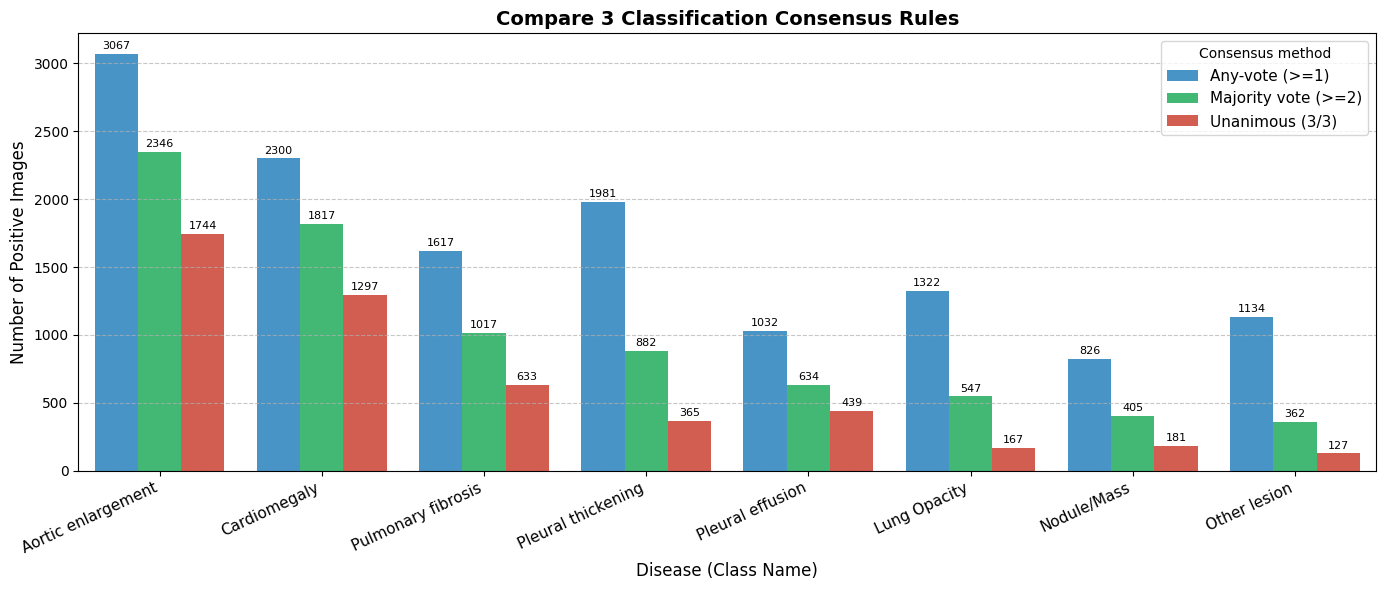

,Class,Any-vote (>=1),Majority vote (>=2),Majority vote (%),Unanimous (3/3),Unanimous (%)
0,Aortic enlargement,3067,2346,76.5,1744,56.9
1,Cardiomegaly,2300,1817,79.0,1297,56.4
2,Pulmonary fibrosis,1617,1017,62.9,633,39.1
3,Pleural thickening,1981,882,44.5,365,18.4
4,Pleural effusion,1032,634,61.4,439,42.5
5,Lung Opacity,1322,547,41.4,167,12.6
6,Nodule/Mass,826,405,49.0,181,21.9
7,Other lesion,1134,362,31.9,127,11.2


In [17]:
agreement_counts = doctor_agreement.copy()

# EXAMPLE: use for 8 most common local classes
top_classes = top8_classes
filtered_agreements = agreement_counts[agreement_counts['class_name'].isin(top_classes)]

# positive sample counts for each class and each voting rule
comparison_data = []
for cname in top_classes:
    c_df = filtered_agreements[filtered_agreements['class_name'] == cname]
    
    any_vote = (c_df['doctor_votes'] >= 1).sum()       # Any-vote (>= 1)
    majority_vote = (c_df['doctor_votes'] >= 2).sum()  # Majority vote (>= 2)
    unanimous_vote = (c_df['doctor_votes'] == 3).sum() # Unanimous vote (3/3)
    
    comparison_data.append({
        'Class': cname,
        'Any-vote (>=1)': any_vote,
        'Majority vote (>=2)': majority_vote,
        'Unanimous (3/3)': unanimous_vote,
        'Majority vote (%)': (majority_vote / any_vote) * 100 if any_vote > 0 else 0,
        'Unanimous (%)': (unanimous_vote / any_vote) * 100 if any_vote > 0 else 0
    })

df_comparison = pd.DataFrame(comparison_data)

# plot per consensus method
df_plot = df_comparison.melt(
    id_vars=['Class'], 
    value_vars=['Any-vote (>=1)', 'Majority vote (>=2)', 'Unanimous (3/3)'],
    var_name='Rule', 
    value_name='Positive Samples'
)

plt.figure(figsize=(14, 6))
palette = {'Any-vote (>=1)': '#3498db', 'Majority vote (>=2)': '#2ecc71', 'Unanimous (3/3)': '#e74c3c'}

ax = sns.barplot(data=df_plot, x='Class', y='Positive Samples', hue='Rule', palette=palette)
plt.title("Compare 3 Classification Consensus Rules", fontsize=14, fontweight='bold')
plt.xlabel("Disease (Class Name)", fontsize=12)
plt.ylabel("Number of Positive Images", fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Consensus method", fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 4. detailed table of retention rates
from IPython.display import display
display(df_comparison[['Class', 'Any-vote (>=1)', 'Majority vote (>=2)', 'Majority vote (%)', 'Unanimous (3/3)', 'Unanimous (%)']].round(1))

df_comparison.to_csv(
    EDA_DIR / "classification_consensus_comparison.csv",
    index=False,
)

,eligible_image_finding_pairs,mean_iou,median_iou
class_name,,,
Aortic enlargement,2346,0.682935,0.701923
Atelectasis,62,0.483300,0.534034
Calcification,177,0.486023,0.528163
Cardiomegaly,1817,0.730860,0.740626
Consolidation,121,0.579347,0.640910
ILD,152,0.531335,0.556492
Infiltration,245,0.510682,0.545400
Lung Opacity,547,0.458203,0.474062
Nodule/Mass,405,0.552275,0.638387


Reader pairs: 19357
Zero-IoU reader pairs: 462


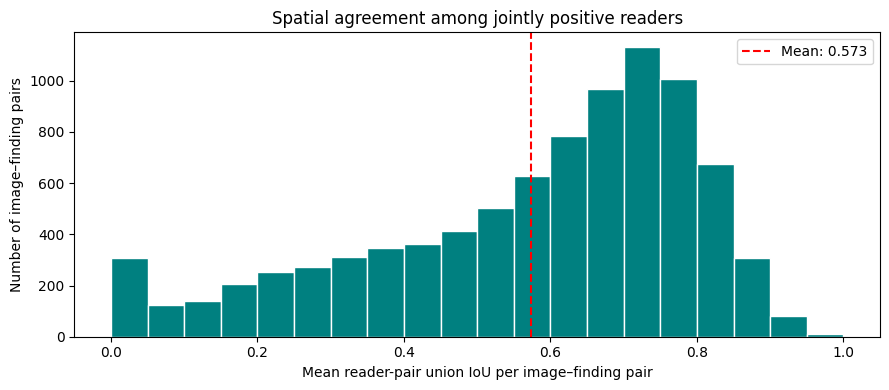

In [18]:
def union_region_iou(boxes_a, boxes_b):
    """
    Exact area IoU between two unions of axis-aligned rectangles.

    Coordinates must already pass the bbox audit.
    """
    boxes_a = np.asarray(boxes_a, dtype=float).reshape(-1, 4)
    boxes_b = np.asarray(boxes_b, dtype=float).reshape(-1, 4)

    if len(boxes_a) == 0 or len(boxes_b) == 0:
        raise ValueError("Both readers must have at least one bbox.")

    all_boxes = np.concatenate([boxes_a, boxes_b], axis=0)

    # Box edges partition the plane into cells whose coverage
    # is constant inside each cell.
    xs = np.unique(all_boxes[:, [0, 2]].ravel())
    ys = np.unique(all_boxes[:, [1, 3]].ravel())

    x_mid = (xs[:-1] + xs[1:]) / 2
    y_mid = (ys[:-1] + ys[1:]) / 2

    grid_x, grid_y = np.meshgrid(x_mid, y_mid)

    cell_areas = (
        np.diff(ys)[:, None]
        * np.diff(xs)[None, :]
    )

    def covered_region(boxes):
        covered = np.zeros(grid_x.shape, dtype=bool)

        for x0, y0, x1, y1 in boxes:
            covered |= (
                (grid_x >= x0)
                & (grid_x < x1)
                & (grid_y >= y0)
                & (grid_y < y1)
            )

        return covered

    region_a = covered_region(boxes_a)
    region_b = covered_region(boxes_b)

    intersection = cell_areas[region_a & region_b].sum()
    union = cell_areas[region_a | region_b].sum()

    if union <= 0:
        raise ValueError("The union region has zero area.")

    return float(intersection / union)


pair_rows = []

for (image_id, class_name), group in df_findings.groupby(
    ["image_id", "class_name"]
):
    reader_boxes = {
        reader: rows[BOX_COLUMNS].to_numpy(dtype=float)
        for reader, rows in group.groupby("rad_id")
    }

    for reader_a, reader_b in combinations(
        sorted(reader_boxes),
        2,
    ):
        iou = union_region_iou(
            reader_boxes[reader_a],
            reader_boxes[reader_b],
        )

        pair_rows.append({
            "image_id": image_id,
            "class_name": class_name,
            "reader_a": reader_a,
            "reader_b": reader_b,
            "iou": iou,
        })

pair_ious = pd.DataFrame(
    pair_rows,
    columns=[
        "image_id",
        "class_name",
        "reader_a",
        "reader_b",
        "iou",
    ],
)

if pair_ious.empty:
    raise ValueError("No jointly positive reader pairs are available.")

# Average reader-pair IoUs within each image-finding pair.
image_finding_ious = (
    pair_ious.groupby(["image_id", "class_name"])["iou"]
    .mean()
    .rename("mean_reader_pair_iou")
    .reset_index()
)

spatial_summary = (
    image_finding_ious.groupby("class_name")
    ["mean_reader_pair_iou"]
    .agg(
        eligible_image_finding_pairs="size",
        mean_iou="mean",
        median_iou="median",
    )
)

display(spatial_summary)

print("Reader pairs:", len(pair_ious))
print(
    "Zero-IoU reader pairs:",
    int(pair_ious["iou"].eq(0).sum()),
)

values = image_finding_ious["mean_reader_pair_iou"]

plt.figure(figsize=(9, 4))
plt.hist(
    values,
    bins=np.linspace(0, 1, 21),
    color="teal",
    edgecolor="white",
)

plt.axvline(
    values.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {values.mean():.3f}",
)

plt.title("Spatial agreement among jointly positive readers")
plt.xlabel("Mean reader-pair union IoU per image–finding pair")
plt.ylabel("Number of image–finding pairs")
plt.legend()
plt.tight_layout()
plt.savefig(
    EDA_DIR / "spatial_agreement_iou.png",
    dpi=150,
)
plt.show()

pair_ious.to_csv(
    EDA_DIR / "reader_pair_union_iou.csv",
    index=False,
)

image_finding_ious.to_csv(
    EDA_DIR / "image_finding_union_iou.csv",
    index=False,
)

spatial_summary.to_csv(
    EDA_DIR / "spatial_agreement_summary.csv",
)

# Problem 3: Multi-label distributions

Construct one binary label vector per image using hard majority
voting: at least two of three readers must report a finding.

Analyze:
- The number of positive findings per image.
- Finding co-occurrence counts.
- Positive and negative counts per finding.

The class-weight ratios computed here are descriptive.
Training pos_weight must be recalculated from the training split only.

Zero selected findings does not necessarily mean No finding.

,image_count
positive_finding_count,
0,10648
1,1476
2,1842
3,637
4,269
5,99
6,21
7,7
8,1


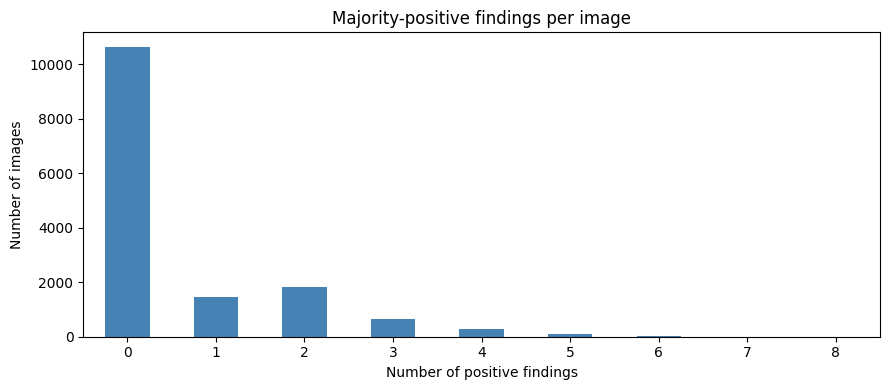

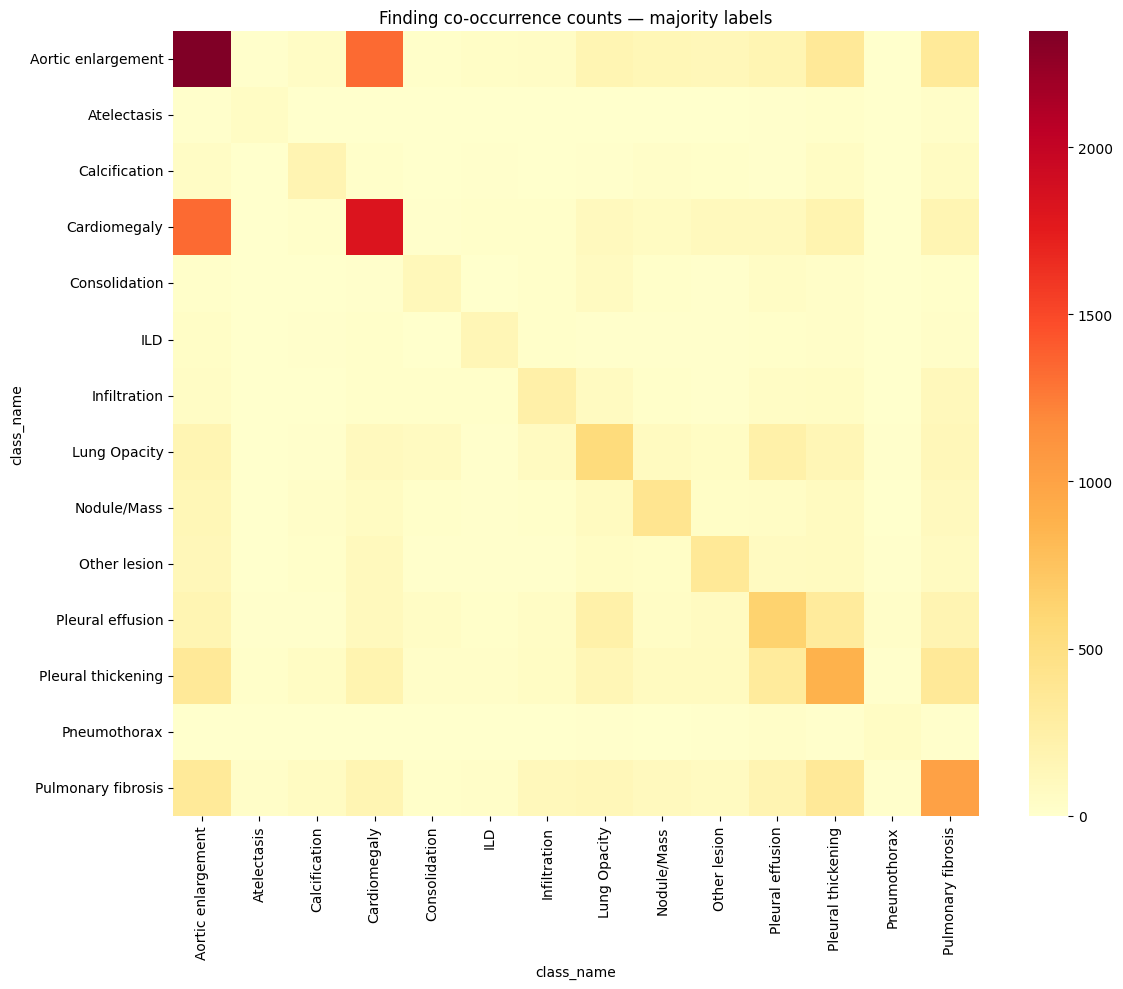

,positive,negative,positive_rate,descriptive_neg_pos_ratio,has_both_classes
class_name,,,,,
Aortic enlargement,2346,12654,0.156400,5.393862,True
Cardiomegaly,1817,13183,0.121133,7.255366,True
Pulmonary fibrosis,1017,13983,0.067800,13.749263,True
Pleural thickening,882,14118,0.058800,16.006803,True
Pleural effusion,634,14366,0.042267,22.659306,True
Lung Opacity,547,14453,0.036467,26.422303,True
Nodule/Mass,405,14595,0.027000,36.037037,True
Other lesion,362,14638,0.024133,40.436464,True
Infiltration,245,14755,0.016333,60.224490,True


In [19]:
ALL_IMAGE_IDS = sorted(df["image_id"].unique())
FINDING_ORDER = sorted(LOCAL_LABELS)

vote_matrix = (
    doctor_agreement.pivot(
        index="image_id",
        columns="class_name",
        values="doctor_votes",
    )
    .reindex(
        index=ALL_IMAGE_IDS,
        columns=FINDING_ORDER,
    )
    .fillna(0)
    .astype("int64")
)

label_matrix = (
    vote_matrix >= POSITIVE_VOTES
).astype("int64")

assert label_matrix.index.is_unique
assert len(label_matrix) == total_images

# Number of majority-positive findings per image.
findings_per_image = label_matrix.sum(axis=1)

finding_count_distribution = (
    findings_per_image.value_counts()
    .sort_index()
    .rename_axis("positive_finding_count")
    .rename("image_count")
)

display(finding_count_distribution.to_frame())

finding_count_distribution.plot.bar(
    figsize=(9, 4),
    color="steelblue",
)

plt.title("Majority-positive findings per image")
plt.xlabel("Number of positive findings")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    EDA_DIR / "findings_per_image.png",
    dpi=150,
)
plt.show()

# Each entry counts images positive for both findings.
cooccurrence = label_matrix.T @ label_matrix

plt.figure(figsize=(12, 10))
sns.heatmap(
    cooccurrence,
    cmap="YlOrRd",
    annot=len(FINDING_ORDER) <= 10,
    fmt="d",
)

plt.title("Finding co-occurrence counts — majority labels")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "finding_cooccurrence.png",
    dpi=150,
)
plt.show()

positive_counts = label_matrix.sum(axis=0)
negative_counts = len(label_matrix) - positive_counts

class_balance = pd.DataFrame({
    "positive": positive_counts,
    "negative": negative_counts,
})

class_balance["positive_rate"] = (
    class_balance["positive"] / len(label_matrix)
)

class_balance["descriptive_neg_pos_ratio"] = (
    class_balance["negative"]
    / class_balance["positive"].replace(0, np.nan)
)

class_balance["has_both_classes"] = (
    class_balance["positive"].gt(0)
    & class_balance["negative"].gt(0)
)

display(
    class_balance.sort_values(
        "positive",
        ascending=False,
    )
)

label_matrix.to_csv(
    EDA_DIR / "majority_labels_eda.csv",
    index_label="image_id",
)

cooccurrence.to_csv(
    EDA_DIR / "finding_cooccurrence.csv",
)

class_balance.to_csv(
    EDA_DIR / "class_balance_eda.csv",
)

finding_count_distribution.to_csv(
    EDA_DIR / "findings_per_image.csv",
)

# Problem 4: Bounding-box size distribution

Measure each annotation box relative to its JPG dimensions:
- Relative width.
- Relative height.
- Relative area.

These are annotation-level measurements.
Multiple readers may annotate the same finding on one image.

,box_count,mean,median,p10,p90
class_name,,,,,
Nodule/Mass,2580,0.009908,0.001376,0.000243,0.026715
Calcification,960,0.012405,0.003801,0.000532,0.033620
Pleural thickening,4842,0.008409,0.004406,0.001602,0.016976
Pleural effusion,2476,0.039518,0.008785,0.002047,0.131824
Pulmonary fibrosis,4655,0.020245,0.010561,0.001702,0.052626
Aortic enlargement,7162,0.016003,0.013690,0.008411,0.024063
Other lesion,2203,0.036060,0.016856,0.000856,0.092389
Lung Opacity,2483,0.034256,0.021049,0.003569,0.078729
Consolidation,556,0.044354,0.032262,0.008945,0.094717


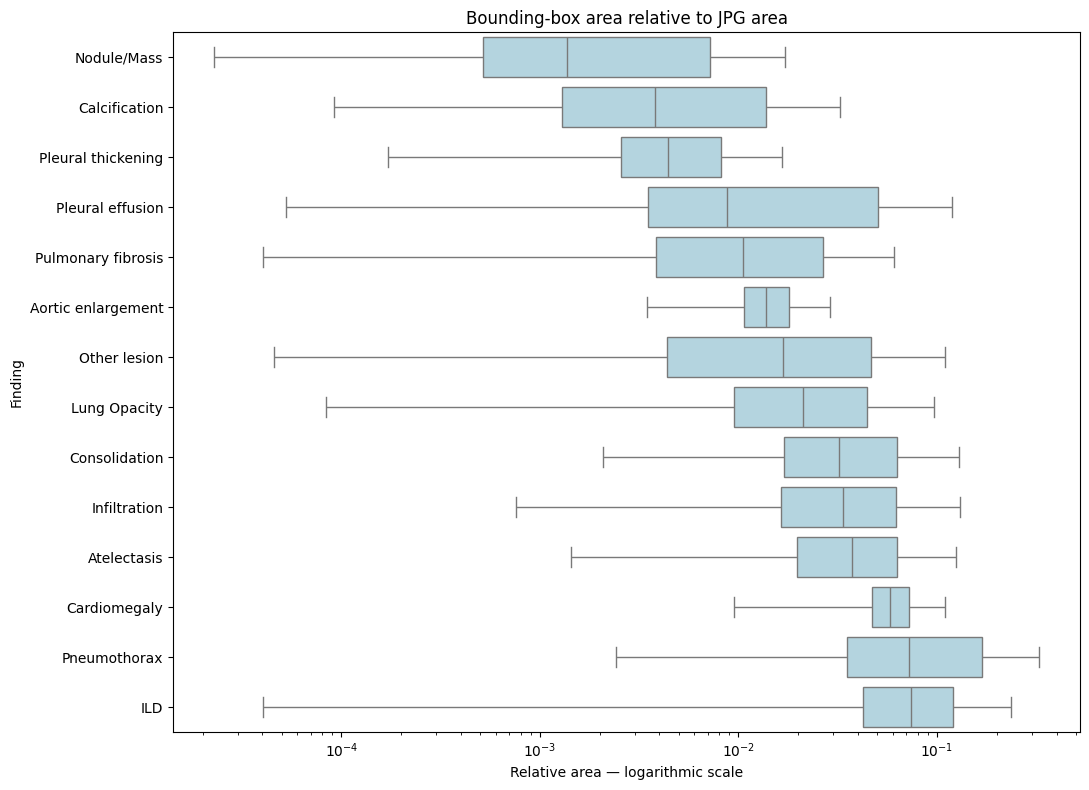

In [20]:
bbox_stats = bbox_audit.copy()

bbox_stats["relative_width"] = (
    (bbox_stats["x_max"] - bbox_stats["x_min"])
    / bbox_stats["jpg_width"]
)

bbox_stats["relative_height"] = (
    (bbox_stats["y_max"] - bbox_stats["y_min"])
    / bbox_stats["jpg_height"]
)

bbox_stats["relative_area"] = (
    bbox_stats["relative_width"]
    * bbox_stats["relative_height"]
)

assert bbox_stats["relative_area"].gt(0).all()
assert bbox_stats["relative_area"].le(1).all()

bbox_size_summary = (
    bbox_stats.groupby("class_name")["relative_area"]
    .agg(
        box_count="size",
        mean="mean",
        median="median",
        p10=lambda values: values.quantile(0.10),
        p90=lambda values: values.quantile(0.90),
    )
    .sort_values("median")
)

display(bbox_size_summary)

plt.figure(figsize=(11, 8))

sns.boxplot(
    data=bbox_stats,
    x="relative_area",
    y="class_name",
    order=bbox_size_summary.index.tolist(),
    showfliers=False,
    color="lightblue",
)

plt.title("Bounding-box area relative to JPG area")
plt.xlabel("Relative area — logarithmic scale")
plt.ylabel("Finding")
plt.xscale("log")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "bbox_relative_area.png",
    dpi=150,
)
plt.show()

bbox_stats.to_csv(
    EDA_DIR / "bbox_size_statistics.csv",
    index=False,
)

bbox_size_summary.to_csv(
    EDA_DIR / "bbox_size_summary.csv",
)

# Problem 5: Consensus visualization

For one image and one finding, visualize:
- Original reader bounding boxes.
- A binary mask for each recorded reader.
- The union of reader masks.
- The fraction of readers covering each pixel.
- Pixels covered by at least two of three readers.

Each reader contributes at most one vote per pixel, even when
their own boxes overlap.

The initial candidate protocol uses:
- Image-level positive: at least two of three readers.
- Localization target: union of reader boxes for a positive finding.

The masks are derived from bounding boxes.
They are not lesion segmentation annotations.

Image: 982f677d3e934cc99a7560f143b7eb49
Finding: Aortic enlargement
Positive readers: 3
Majority classification label: 1
Localization supervision valid: True


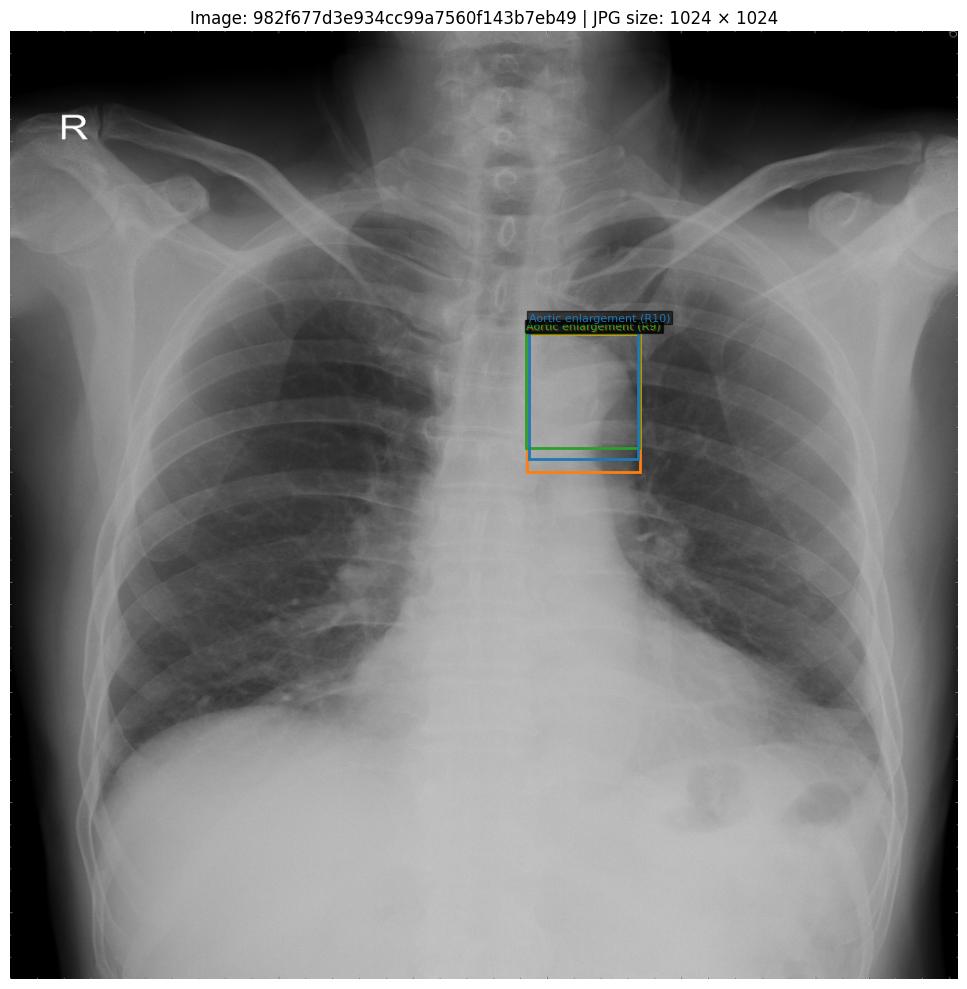

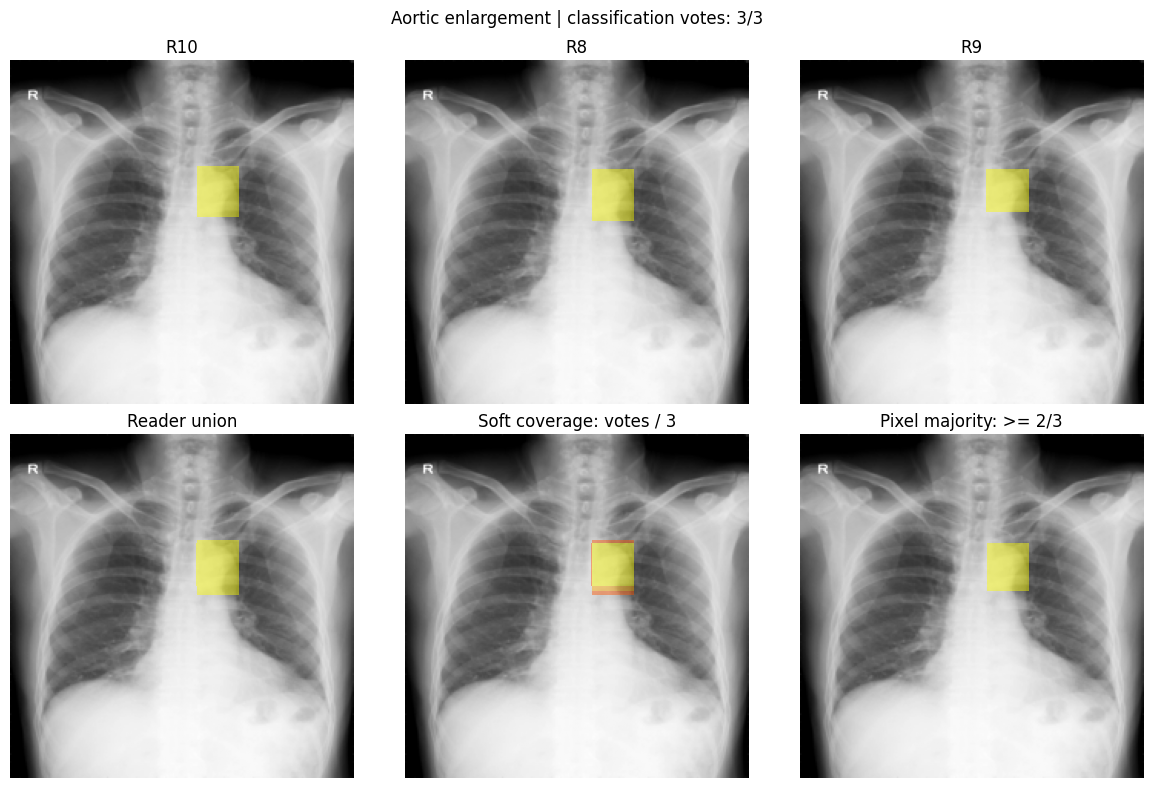

Image: 4552f5fcf83d643416d9da169bfbba67
Finding: Aortic enlargement
Positive readers: 3
Majority classification label: 1
Localization supervision valid: True


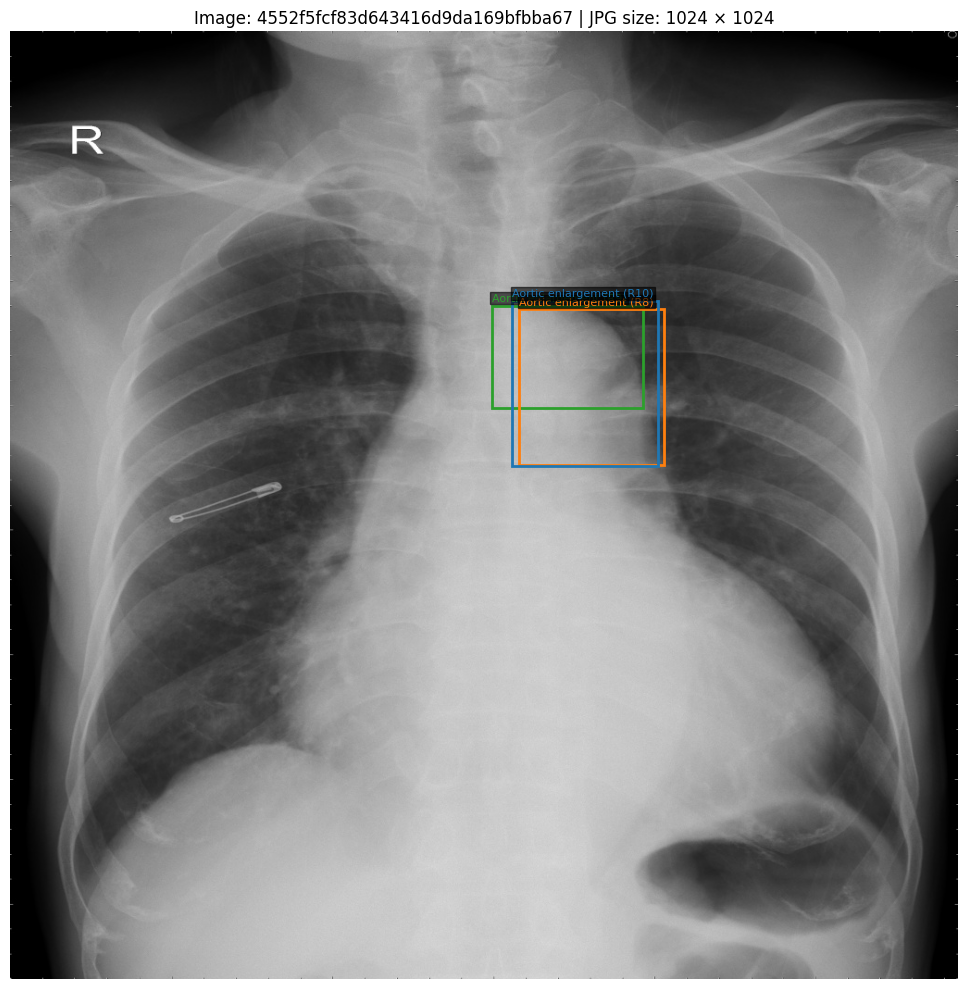

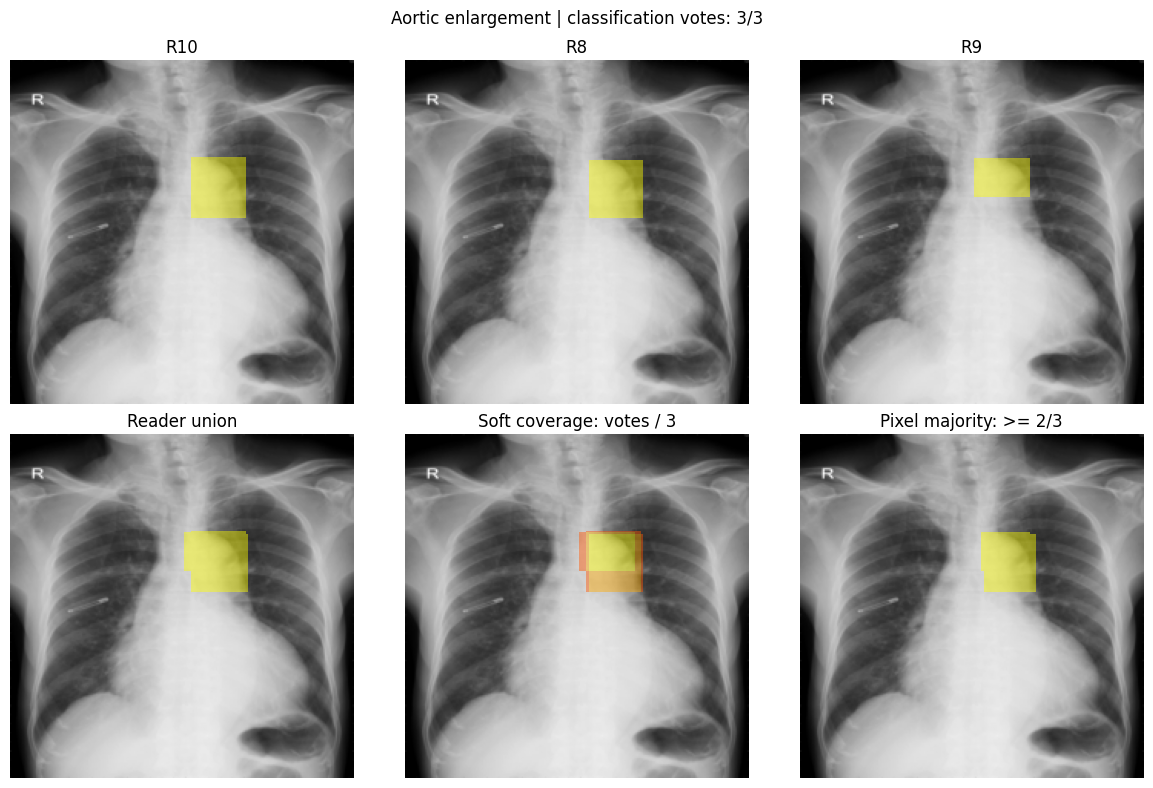

In [21]:
MASK_SIZE = 224

def make_reader_masks(image_id, class_name, size=224):
    width, height = image_dimensions[image_id]

    # Include all recorded readers, including those who
    # did not report this particular finding.
    readers = sorted(
        df.loc[
            df["image_id"].eq(image_id),
            "rad_id",
        ].unique()
    )

    if len(readers) != EXPECTED_READERS:
        raise ValueError("Unexpected reader count.")

    rows = df_findings.loc[
        df_findings["image_id"].eq(image_id)
        & df_findings["class_name"].eq(class_name)
    ]

    masks = {
        reader: np.zeros((size, size), dtype=bool)
        for reader in readers
    }

    for row in rows.itertuples(index=False):
        x0 = int(np.floor(row.x_min / width * size))
        y0 = int(np.floor(row.y_min / height * size))
        x1 = int(np.ceil(row.x_max / width * size))
        y1 = int(np.ceil(row.y_max / height * size))

        x0, x1 = np.clip([x0, x1], 0, size)
        y0, y1 = np.clip([y0, y1], 0, size)

        # Boolean union within one reader prevents double voting.
        masks[row.rad_id][y0:y1, x0:x1] = True

    return masks


def visualize_consensus(image_id, class_name):
    reader_masks = make_reader_masks(
        image_id,
        class_name,
        size=MASK_SIZE,
    )

    mask_stack = np.stack(
        list(reader_masks.values())
    )

    pixel_votes = mask_stack.sum(axis=0)

    union_mask = pixel_votes >= 1
    soft_mask = pixel_votes / EXPECTED_READERS
    pixel_majority_mask = pixel_votes >= POSITIVE_VOTES

    positive_reader_count = int(
        vote_matrix.loc[image_id, class_name]
    )

    classification_positive = (
        positive_reader_count >= POSITIVE_VOTES
    )

    target_mask = (
        union_mask.copy()
        if classification_positive
        else np.zeros_like(union_mask)
    )

    print("Image:", image_id)
    print("Finding:", class_name)
    print("Positive readers:", positive_reader_count)
    print("Majority classification label:", int(classification_positive))
    print(
        "Localization supervision valid:",
        bool(classification_positive and target_mask.any()),
    )

    plot_cxr_img(
        image_id,
        df,
        TRAIN_DIR,
        class_name=class_name,
    )

    image_path = image_paths[image_id]

    with Image.open(image_path) as source:
        resized = source.convert("L").resize(
            (MASK_SIZE, MASK_SIZE),
            Image.Resampling.BILINEAR,
        )
        image_array = np.asarray(resized)

    panels = [
        (reader, mask.astype(float))
        for reader, mask in reader_masks.items()
    ]

    panels += [
        ("Reader union", union_mask.astype(float)),
        ("Soft coverage: votes / 3", soft_mask),
        ("Pixel majority: >= 2/3", pixel_majority_mask.astype(float)),
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12, 8),
    )

    for ax, (title, mask) in zip(axes.ravel(), panels):
        ax.imshow(image_array, cmap="gray")

        ax.imshow(
            np.ma.masked_where(mask == 0, mask),
            cmap="autumn",
            vmin=0,
            vmax=1,
            alpha=0.45,
            interpolation="nearest",
        )

        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(
        f"{class_name} | classification votes: "
        f"{positive_reader_count}/3"
    )
    plt.tight_layout()
    plt.show()

    return {
        "reader_masks": reader_masks,
        "union_mask": union_mask,
        "soft_mask": soft_mask,
        "pixel_majority_mask": pixel_majority_mask,
        "target_mask": target_mask,
        "classification_positive": classification_positive,
    }


# Pick a finding with at least one majority-positive image.
eligible_findings = (
    summary.loc[
        summary["finding"].isin(FINDING_ORDER)
        & summary["positive_majority"].gt(0),
        "finding",
    ]
    .tolist()
)

if not eligible_findings:
    raise ValueError("No majority-positive finding is available.")

# Can be change for testing 
DEMO_FINDING = eligible_findings[0]

positive_ids = label_matrix.index[
    label_matrix[DEMO_FINDING].eq(1)
].to_series()

demo_ids = positive_ids.sample(
    n=min(2, len(positive_ids)),
    random_state=42,
)

for image_id in demo_ids:
    demo = visualize_consensus(
        image_id,
        DEMO_FINDING,
    )

# EDA conclusions and pending decisions

## Data coverage
- Dataset source and version:
- Image format:
- Available annotation files:
- Number of annotated images:
- Number of annotation rows:
- Observed label names:
- Reader-count audit result:

## Bounding-box validation
- Coordinate system:
- Invalid bounding-box count:
- Missing image-file count:
- Unannotated JPG count:
- Visual overlay inspection result:

## Candidate classification protocol
- Positive: at least two of three readers report the finding.
- Negative: zero or one positive reader under hard majority voting.
- The one-reader group remains available for sensitivity analysis.

## Candidate localization protocol
- Use the union of reader bounding boxes for majority-positive findings.
- Do not apply localization supervision to classification-negative findings.
- Bounding-box masks are region proxies, not segmentation ground truth.

## Selected findings
- Finding names:
- Majority-positive image counts:
- Spatial agreement:
- Relative bounding-box sizes:
- Selection rationale:

## Pending decisions
- Confirm independent test-label availability.
- Confirm the final target-finding list.
- Freeze the annotation and mask rules.
- Create fixed train/validation splits.
- Calculate training class weights from the training split only.